---
# Machine learning : `spam`
---

## Packages

In [111]:
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.inspection import permutation_importance
from sklearn.model_selection import GridSearchCV, train_test_split

from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree

from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

import time

---
## 1. Données
---

### 1.1. Importation

In [112]:
# En local :
directory = 'data/'

# Sur Google collab ou Onyxia (sur un répertoire temporaire) :
# directory = ''

# Sur Google collab (sur le drive) :
# from google.colab import drive
# drive.mount('/content/drive')
# directory = '/content/drive/MyDrive/Data/'

In [113]:
data = pd.read_csv(directory + 'spam.csv',
                   header    = 0,
                   index_col = 0,
                   sep       = ',',
                   decimal   = '.')

In [114]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Float64Index: 4601 entries, 0.0 to 0.0
Data columns (total 57 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   word_freq_address           4601 non-null   float64
 1   word_freq_all               4601 non-null   float64
 2   word_freq_3d                4601 non-null   float64
 3   word_freq_our               4601 non-null   float64
 4   word_freq_over              4601 non-null   float64
 5   word_freq_remove            4601 non-null   float64
 6   word_freq_internet          4601 non-null   float64
 7   word_freq_order             4601 non-null   float64
 8   word_freq_mail              4601 non-null   float64
 9   word_freq_receive           4601 non-null   float64
 10  word_freq_will              4601 non-null   float64
 11  word_freq_people            4601 non-null   float64
 12  word_freq_report            4601 non-null   float64
 13  word_freq_addresses         46

In [115]:
data.head()

,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,word_freq_receive,...,char_freq_semicolon,char_freq_leftbrac,char_freq_leftsquarebrac,char_freq_exclaim,char_freq_dollar,char_freq_pound,capital_run_length_average,capital_run_length_longest,capital_run_length_total,spam
word_freq_make,,,,,,,,,,,,,,,,,,,,,
0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,0.21,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,0.38,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,0.31,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,0.31,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


### 1.2. Gestion des données manquantes

In [116]:
missing_percentage = data.isna().mean() * 100

print('MISSING VALUES :')
if missing_percentage[missing_percentage != 0].empty:
    print('No')
else:
    print(missing_percentage[missing_percentage != 0].sort_values(ascending=False))

MISSING VALUES :
No


### 1.3. Gestion des variables

In [117]:
target = 'spam'
features = list(data.columns.difference([target]))

X = data[features]
y = data[target]

### 1.4. Création d'un échantillon test

In [118]:
test_portion = 1/5

X_train_valid, X_test, y_train_valid, y_test = train_test_split(X, y, test_size=test_portion)

print('Dimensions X_train_valid :', X_train_valid.shape)
print('Dimensions X_test        :', X_test.shape)
print('Dimensions y_train_valid :', y_train_valid.shape)
print('Dimensions y_test        :', y_test.shape)

Dimensions X_train_valid : (3680, 56)
Dimensions X_test        : (921, 56)
Dimensions y_train_valid : (3680,)
Dimensions y_test        : (921,)


---
## 2. Modélisation
---

In [119]:
criteria = 'accuracy' # Pour le choix du critère CV (-MSE car GridSearchCV maximise le score)
n_folds  = 10                       # Pour le nombre de blocs CV (10)
n_core   = -1                       # Pour l'utilisation de tous les coeurs disponibles
verbose  = 1                        # Pour le caractère "verbeux"

### 2.1. CART

In [120]:
start_time = time.time()

In [121]:
cart_model = DecisionTreeClassifier()
cart = cart_model.fit(X_train_valid, y_train_valid)

In [122]:
y_test_pred_cart = cart.predict(X_test)

In [123]:
end_time = time.time()
execution_time_cart = end_time - start_time
print(f"Temps d'exécution CART : {execution_time_cart:.2f} secondes")

Temps d'exécution CART : 0.10 secondes


In [124]:
cm_cart = confusion_matrix(y_test, y_test_pred_cart)
print("Matrice de confusion de l'arbre :\n", cm_cart)
# Accuracy
accuracy_cart = accuracy_score(y_test, y_test_pred_cart)
print(f"Accuracy : {accuracy_cart:.3f}")

# Precision
precision_cart = precision_score(y_test, y_test_pred_cart)
print(f"Precision : {precision_cart:.3f}")

# Sensibility (Recall)
sensibility_cart = recall_score(y_test, y_test_pred_cart)
print(f"Sensibility (Recall) : {sensibility_cart:.3f}")

# Specificity
tn, fp, fn, tp = cm_cart.ravel()
specificity_cart = tn / (tn + fp)
print(f"Specificity : {specificity_cart:.3f}")

# F1 Score
f1_cart = f1_score(y_test, y_test_pred_cart)
print(f"F1 Score : {f1_cart:.3f}")

Matrice de confusion de l'arbre :
 [[502  51]
 [ 29 339]]
Accuracy : 0.913
Precision : 0.869
Sensibility (Recall) : 0.921
Specificity : 0.908
F1 Score : 0.894


### 2.2. Random forest

In [125]:
start_time = time.time()

In [126]:
rf_model = RandomForestClassifier()

params_rf = {
    'n_estimators': [200, 300, 400, 500]
}

rf = GridSearchCV(estimator  = rf_model,
                  param_grid = params_rf,
                  scoring    = criteria,
                  cv         = n_folds,
                  n_jobs     = n_core,
                  verbose    = verbose)

rf.fit(X_train_valid, y_train_valid)

Fitting 10 folds for each of 4 candidates, totalling 40 fits


GridSearchCV(cv=10, estimator=RandomForestClassifier(), n_jobs=-1,
             param_grid={'n_estimators': [200, 300, 400, 500]},
             scoring='accuracy', verbose=1)

In [127]:
y_test_pred_rf = rf.predict(X_test)

In [128]:
end_time = time.time()
execution_time_rf = end_time - start_time
print(f"Temps d'exécution Random forest : {execution_time_rf:.2f} secondes")

Temps d'exécution Random forest : 12.37 secondes


In [129]:
print('Hyperparamètre optimal Random forest :', rf.best_params_)

Hyperparamètre optimal Random forest : {'n_estimators': 300}


In [130]:
cm_rf = confusion_matrix(y_test, y_test_pred_rf)
print("Matrice de confusion de l'arbre :\n", cm_rf)
# Accuracy
accuracy_rf = accuracy_score(y_test, y_test_pred_rf)
print(f"Accuracy : {accuracy_rf:.3f}")

# Precision
precision_rf = precision_score(y_test, y_test_pred_rf)
print(f"Precision : {precision_rf:.3f}")

# Sensibility (Recall)
sensibility_rf = recall_score(y_test, y_test_pred_rf)
print(f"Sensibility (Recall) : {sensibility_rf:.3f}")

# Specificity
tn, fp, fn, tp = cm_rf.ravel()
specificity_rf = tn / (tn + fp)
print(f"Specificity : {specificity_rf:.3f}")

# F1 Score
f1_rf = f1_score(y_test, y_test_pred_rf)
print(f"F1 Score : {f1_rf:.3f}")

Matrice de confusion de l'arbre :
 [[538  15]
 [ 27 341]]
Accuracy : 0.954
Precision : 0.958
Sensibility (Recall) : 0.927
Specificity : 0.973
F1 Score : 0.942


On peut visualiser les résultats pour potentiellement réduire le nombre d'arbres choisi par validation croisée (si les performances sont proches) :

In [131]:
rf_out = pd.DataFrame(rf.cv_results_)
print(rf_out[['param_n_estimators', 'mean_test_score', 'std_test_score']])

  param_n_estimators  mean_test_score  std_test_score
0                200         0.948098        0.014555
1                300         0.951630        0.013952
2                400         0.951630        0.012676
3                500         0.950815        0.014402


On peut visualiser l'importance des variables :

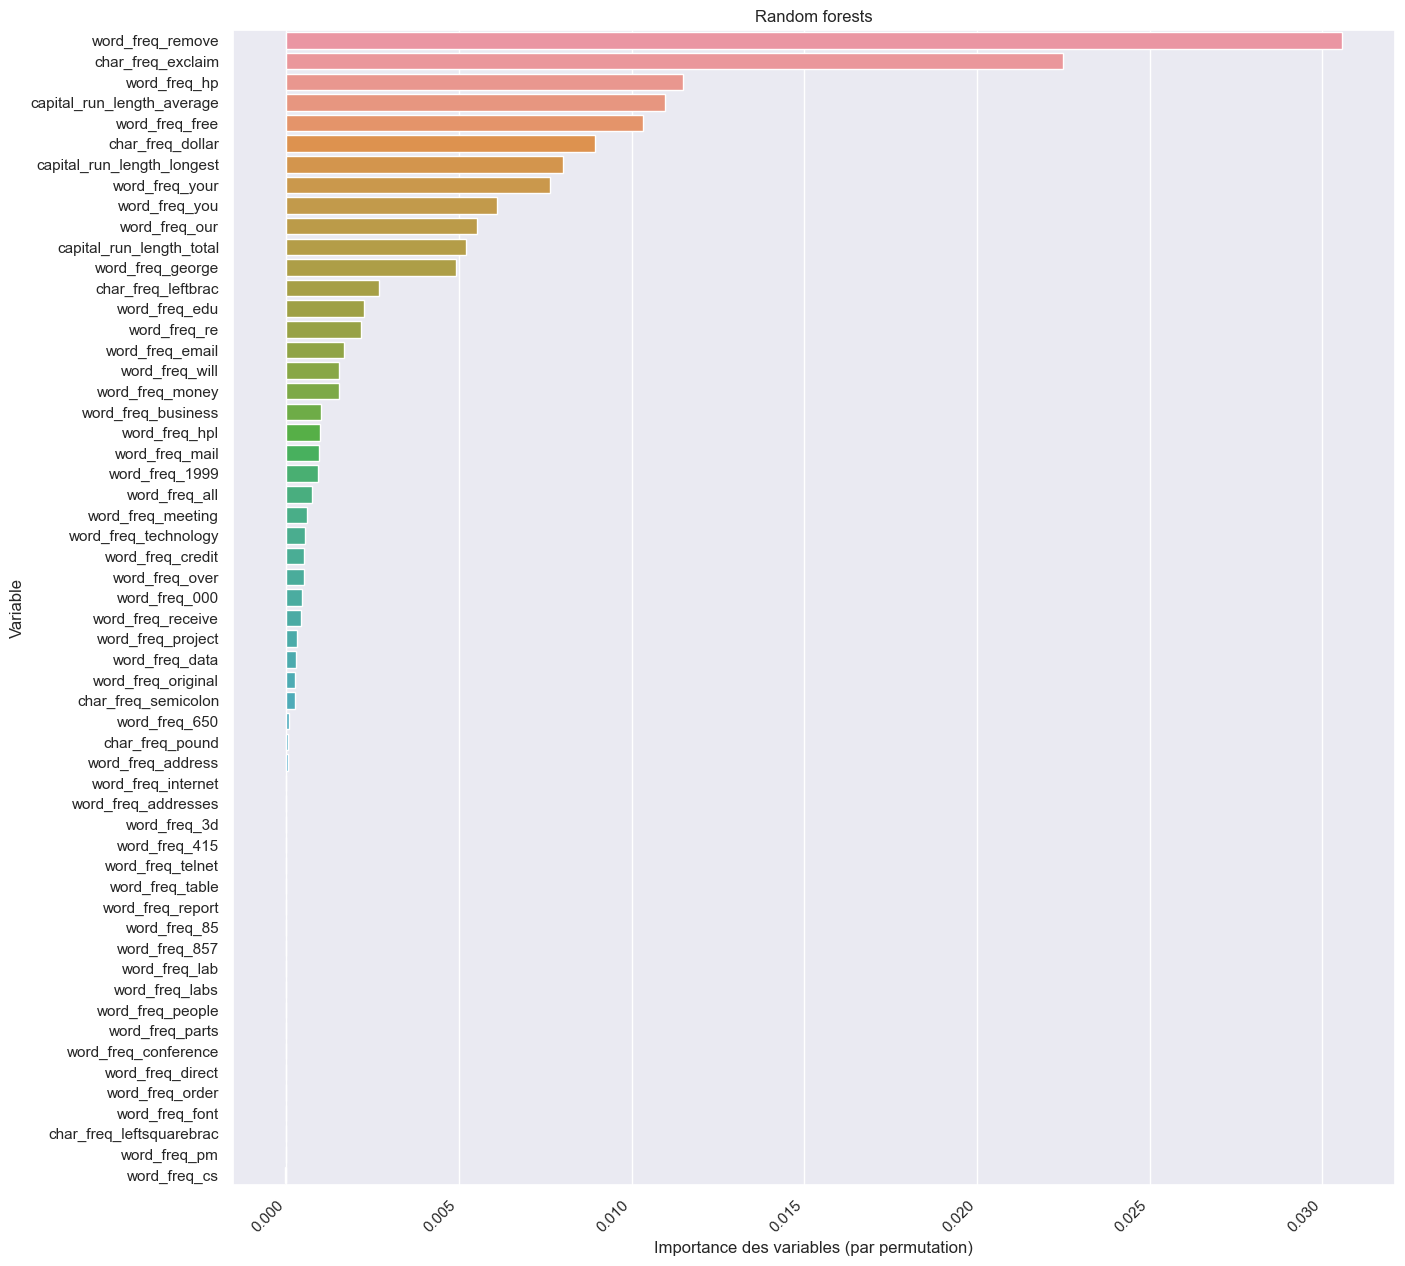

In [132]:
perm_importance_rf = permutation_importance(rf.best_estimator_, X_train_valid, y_train_valid, scoring=criteria, n_repeats=10, n_jobs=n_core)

perm_importance_df = pd.DataFrame({
    'Variable': X_train_valid.columns,
    'Importance': perm_importance_rf.importances_mean
    }).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(15, 15))
sns.barplot(x='Importance', y='Variable', data=perm_importance_df)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Importance des variables (par permutation)')
plt.ylabel('Variable')
plt.title('Random forests')
plt.show()

### 2.3. Gradient boosting

In [133]:
start_time = time.time()

In [134]:
gb_model = HistGradientBoostingClassifier(early_stopping=True, tol=1e-4)

params_gb = {
    'max_iter': [2000],
    'learning_rate': [0.05, 0.1, 0.15, 0.2, 0.25],
    'loss': ['log_loss'],
}

gb = GridSearchCV(estimator  = gb_model,
                  param_grid = params_gb,
                  scoring    = criteria,
                  cv         = n_folds,
                  n_jobs     = n_core,
                  verbose    = verbose)

gb.fit(X_train_valid, y_train_valid)

Fitting 10 folds for each of 5 candidates, totalling 50 fits


GridSearchCV(cv=10,
             estimator=HistGradientBoostingClassifier(early_stopping=True,
                                                      tol=0.0001),
             n_jobs=-1,
             param_grid={'learning_rate': [0.05, 0.1, 0.15, 0.2, 0.25],
                         'loss': ['log_loss'], 'max_iter': [2000]},
             scoring='accuracy', verbose=1)

In [135]:
y_test_pred_gb = gb.predict(X_test)

In [136]:
end_time = time.time()
execution_time_gb = end_time - start_time
print(f"Temps d'exécution Gradient boosting : {execution_time_gb:.2f} secondes")

Temps d'exécution Gradient boosting : 5.51 secondes


In [137]:
print('Hyperparamètres optimaux Gradient boosting :', gb.best_params_)
print("Nombre d'itérations réel Gradient boosting :", gb.best_estimator_.n_iter_)

Hyperparamètres optimaux Gradient boosting : {'learning_rate': 0.05, 'loss': 'log_loss', 'max_iter': 2000}
Nombre d'itérations réel Gradient boosting : 140


In [138]:
cm_gb = confusion_matrix(y_test, y_test_pred_gb)
print("Matrice de confusion de l'arbre :\n", cm_gb)
# Accuracy
accuracy_gb = accuracy_score(y_test, y_test_pred_gb)
print(f"Accuracy : {accuracy_gb:.3f}")

# Precision
precision_gb = precision_score(y_test, y_test_pred_gb)
print(f"Precision : {precision_gb:.3f}")

# Sensibility (Recall)
sensibility_gb = recall_score(y_test, y_test_pred_gb)
print(f"Sensibility (Recall) : {sensibility_gb:.3f}")

# Specificity
tn, fp, fn, tp = cm_gb.ravel()
specificity_gb = tn / (tn + fp)
print(f"Specificity : {specificity_gb:.3f}")

# F1 Score
f1_gb = f1_score(y_test, y_test_pred_gb)
print(f"F1 Score : {f1_gb:.3f}")

Matrice de confusion de l'arbre :
 [[536  17]
 [ 25 343]]
Accuracy : 0.954
Precision : 0.953
Sensibility (Recall) : 0.932
Specificity : 0.969
F1 Score : 0.942


---
## 3. Synthèse
---

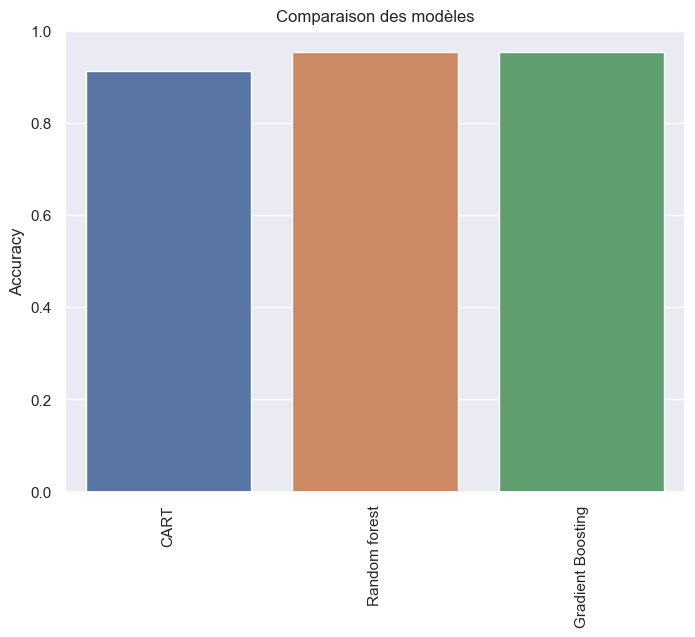

In [139]:
accuracy_model = {}
accuracy_model['CART'] = accuracy_cart
accuracy_model['Random forest'] = accuracy_rf
accuracy_model['Gradient Boosting'] = accuracy_gb
sns.set_theme(style='darkgrid')
fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(x=list(accuracy_model.keys()), y=list(accuracy_model.values()), ax=ax)
ax.tick_params(axis='x', labelrotation=90)
ax.set_ylabel('Accuracy')
ax.set_title('Comparaison des modèles')
plt.show()

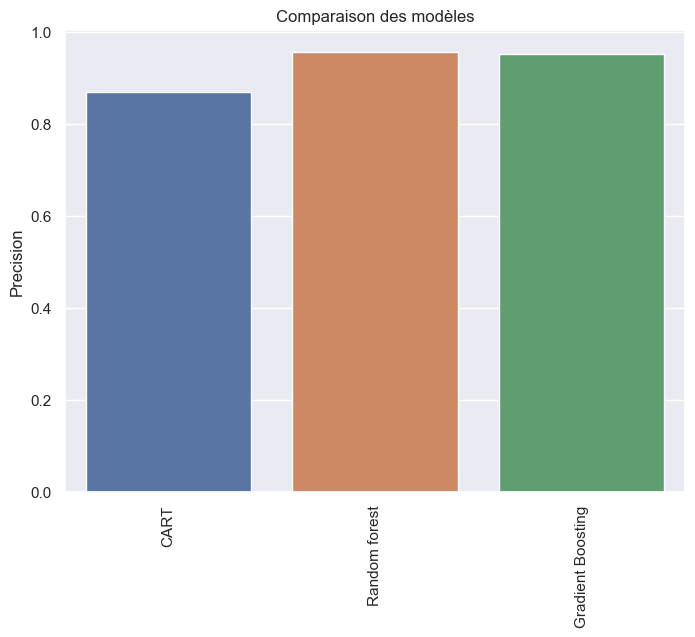

In [140]:
precision_model = {}
precision_model['CART'] = precision_cart
precision_model['Random forest'] = precision_rf
precision_model['Gradient Boosting'] = precision_gb
sns.set_theme(style='darkgrid')
fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(x=list(precision_model.keys()), y=list(precision_model.values()), ax=ax)
ax.tick_params(axis='x', labelrotation=90)
ax.set_ylabel('Precision')
ax.set_title('Comparaison des modèles')
plt.show()

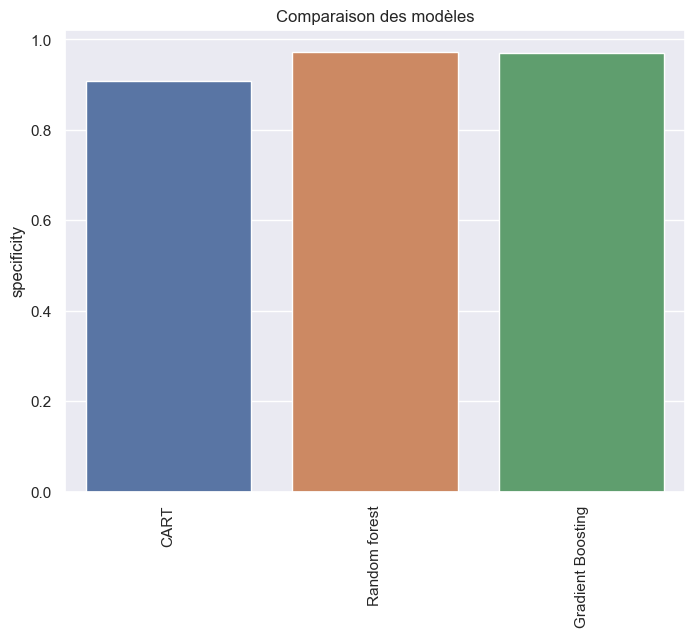

In [141]:
specificity_model = {}
specificity_model['CART'] = specificity_cart
specificity_model['Random forest'] = specificity_rf
specificity_model['Gradient Boosting'] = specificity_gb
sns.set_theme(style='darkgrid')
fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(x=list(specificity_model.keys()), y=list(specificity_model.values()), ax=ax)
ax.tick_params(axis='x', labelrotation=90)
ax.set_ylabel('specificity')
ax.set_title('Comparaison des modèles')
plt.show()

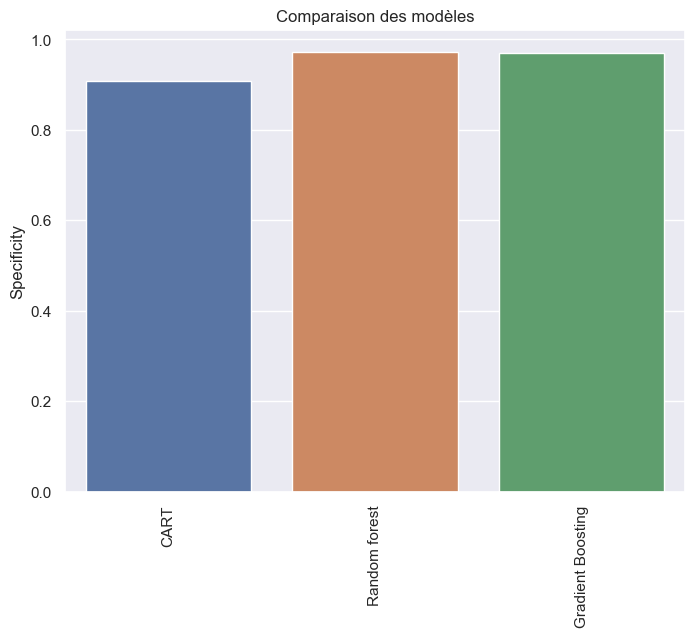

In [142]:
specificity_model = {}
specificity_model['CART'] = specificity_cart
specificity_model['Random forest'] = specificity_rf
specificity_model['Gradient Boosting'] = specificity_gb
sns.set_theme(style='darkgrid')
fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(x=list(specificity_model.keys()), y=list(specificity_model.values()), ax=ax)
ax.tick_params(axis='x', labelrotation=90)
ax.set_ylabel('Specificity')
ax.set_title('Comparaison des modèles')
plt.show()

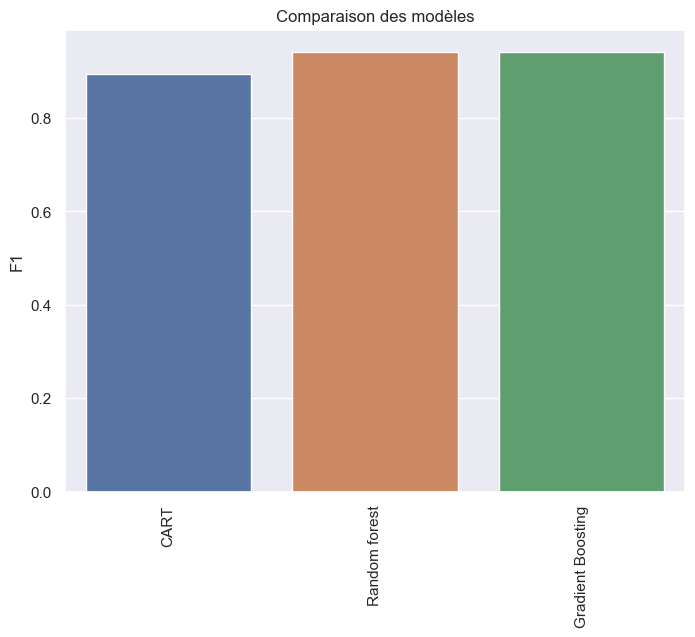

In [143]:
f1_model = {}
f1_model['CART'] = f1_cart
f1_model['Random forest'] = f1_rf
f1_model['Gradient Boosting'] = f1_gb
sns.set_theme(style='darkgrid')
fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(x=list(f1_model.keys()), y=list(f1_model.values()), ax=ax)
ax.tick_params(axis='x', labelrotation=90)
ax.set_ylabel('F1')
ax.set_title('Comparaison des modèles')
plt.show()

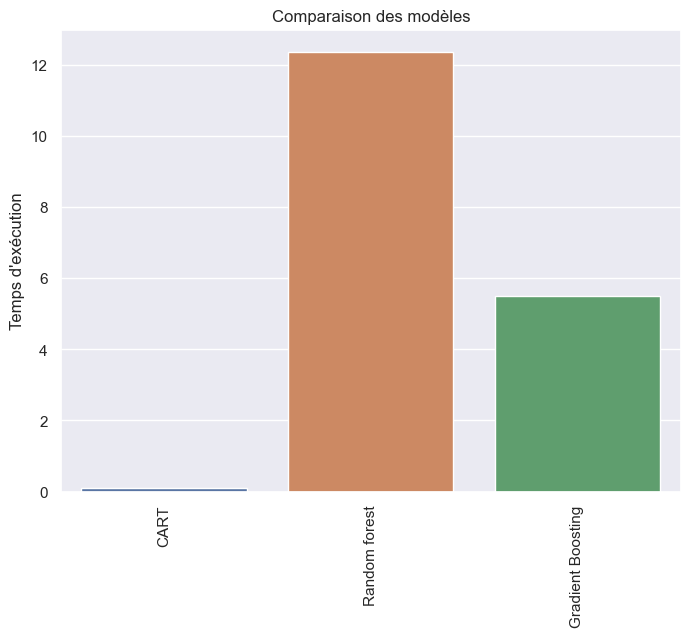

In [144]:
execution_time_model = {}
execution_time_model['CART']              = execution_time_cart
execution_time_model['Random forest']     = execution_time_rf
execution_time_model['Gradient Boosting'] = execution_time_gb

sns.set_theme(style='darkgrid')
fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(x=list(execution_time_model.keys()), y=list(execution_time_model.values()), ax=ax)
ax.tick_params(axis='x', labelrotation=90)
ax.set_ylabel("Temps d'exécution")
ax.set_title('Comparaison des modèles')
plt.show()